In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhuvankumarapatri/brain-tumor")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/bhuvankumarapatri/brain-tumor


In [2]:
# ------------------------------
# IMPORTS
# ------------------------------
import os
import numpy as np
import torch
from torch import amp
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import DataLoader, random_split, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    matthews_corrcoef,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import ttest_rel

from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image

# ------------------------------
# DEVICE
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {device}")


# ------------------------------
# SEED FUNCTION
# ------------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 🔥 Better for performance + AO
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

🚀 Using device: cuda


In [3]:
import os

DATA_DIR = os.path.join(path, "Training")
TEST_DIR = os.path.join(path, "Testing")

def dataset_info(folder_path):
    classes = []
    class_counts = {}
    total_images = 0

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            classes.append(class_name)
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
            total_images += num_images

    return classes, class_counts, total_images


# Training info
train_classes, train_counts, train_total = dataset_info(DATA_DIR)

# Testing info
test_classes, test_counts, test_total = dataset_info(TEST_DIR)

# Print results
print("📊 TRAINING DATASET")
print("Classes:", train_classes)
print("Number of classes:", len(train_classes))
print("Class-wise count:", train_counts)
print("Total images:", train_total)

print("\n📊 TESTING DATASET")
print("Classes:", test_classes)
print("Number of classes:", len(test_classes))
print("Class-wise count:", test_counts)
print("Total images:", test_total)

print("\n📊 OVERALL")
print("Total images (Train + Test):", train_total + test_total)

📊 TRAINING DATASET
Classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Number of classes: 4
Class-wise count: {'pituitary': 1457, 'notumor': 1595, 'meningioma': 1339, 'glioma': 1321}
Total images: 5712

📊 TESTING DATASET
Classes: ['pituitary', 'notumor', 'meningioma', 'glioma']
Number of classes: 4
Class-wise count: {'pituitary': 300, 'notumor': 405, 'meningioma': 306, 'glioma': 300}
Total images: 1311

📊 OVERALL
Total images (Train + Test): 7023


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# load WITHOUT transform
full_dataset = datasets.ImageFolder(DATA_DIR)
num_classes = len(full_dataset.classes)

labels = full_dataset.targets

# stratified split
train_idx, val_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

#  separate transforms
train_ds = Subset(
    datasets.ImageFolder(DATA_DIR, transform=train_transform),
    train_idx
)

val_ds = Subset(
    datasets.ImageFolder(DATA_DIR, transform=test_transform),
    val_idx
)

test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transform)

print("Classes:", full_dataset.classes)
print(len(train_ds), len(val_ds), len(test_ds))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
4569 1143 1311


In [5]:
def evaluate(model, loader):
    model.eval()
    y_true, y_pred, y_score = [], [], []
    
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device)

            # AMP forward
            with amp.autocast(device_type='cuda'):
                out = model(x)

            # Softmax (stable + detached)
            probs = torch.softmax(out, dim=1).detach().cpu().numpy()
            y_score.extend(probs)

            preds = out.argmax(dim=1)
            y_pred.extend(preds.cpu().numpy())

            y_true.extend(y.cpu().numpy())

    final_acc = np.mean(np.array(y_true) == np.array(y_pred))

    return final_acc, np.array(y_pred), np.array(y_true), np.array(y_score)

In [6]:
# ------------------------------
# MODEL BUILDER
# ------------------------------
def build_convnext(dropout, num_classes):
    model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)

# ------------------------------
# BASELINE HYPERPARAMETERS
# ------------------------------
learning_rate = 3e-4
dropout_rate = 0.1
batch_size = 32
epochs = 20
num_classes = 4

# ------------------------------
# BUILD MODEL
# ------------------------------
model_cnx = build_convnext(dropout_rate, num_classes)

# ------------------------------
# LOSS & OPTIMIZER
# ------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_cnx.parameters(), lr=learning_rate)

# ------------------------------
# SCHEDULER (MATCH AO)
# ------------------------------
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# ------------------------------
# DATALOADERS (OPTIMIZED)
# ------------------------------
is_cuda = (device.type == "cuda")

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=is_cuda
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=is_cuda
)

# ------------------------------
# TRAINING FUNCTION (AMP ENABLED)
# ------------------------------
def train_model_full(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs):

    history = {
        "train_acc": [], "val_acc": [],
        "train_loss": [], "val_loss": []
    }

    best_val_acc = 0.0
    patience = 5
    counter = 0

    scaler = amp.GradScaler() # 🔥 SAME AS AO

    for epoch in range(1, epochs + 1):

        # ===== TRAIN =====
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            with amp.autocast(device_type='cuda'):  # 🔥 AMP
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        # 🔥 Scheduler step
        scheduler.step()

        train_loss = running_loss / total
        train_acc = correct / total

        # ===== VALIDATION =====
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.inference_mode():  # 🔥 SAME AS AO
            for images, labels in val_loader:

                images, labels = images.to(device), labels.to(device)

                with amp.autocast(device_type='cuda'):  # 🔥 AMP in validation
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                preds = outputs.argmax(1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        # ===== SAVE HISTORY =====
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f"Epoch {epoch}/{epochs} | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # ===== SAVE BEST MODEL =====
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            counter = 0
            torch.save(model.state_dict(), "best_convnext_baseline.pth")
            print("✅ Best model saved")
        else:
            counter += 1

        # ===== EARLY STOPPING =====
        if counter >= patience:
            print("🛑 Early stopping triggered")
            break

    print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")
    return history

# ------------------------------
# RUN TRAINING
# ------------------------------
history = train_model_full(
    model_cnx,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    epochs
)

# ------------------------------
# LOAD BEST MODEL (SAFE)
# ------------------------------
model_cnx.load_state_dict(torch.load("best_convnext_baseline.pth", map_location=device))
model_cnx.eval()

# ------------------------------
# BEST METRICS SUMMARY
# ------------------------------
best_train_acc = max(history["train_acc"])
best_train_epoch = history["train_acc"].index(best_train_acc) + 1
train_loss_at_best = history["train_loss"][best_train_epoch - 1]

best_val_acc = max(history["val_acc"])
best_val_epoch = history["val_acc"].index(best_val_acc) + 1
val_loss_at_best = history["val_loss"][best_val_epoch - 1]

print(f"\n✅ Best Training Accuracy: {best_train_acc:.4f} at Epoch {best_train_epoch} | Loss: {train_loss_at_best:.4f}")
print(f"✅ Best Validation Accuracy: {best_val_acc:.4f} at Epoch {best_val_epoch} | Loss: {val_loss_at_best:.4f}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 212MB/s] 
Epoch 1/20: 100%|██████████| 143/143 [01:01<00:00,  2.33it/s]


Epoch 1/20 | Train Acc: 0.8971 | Val Acc: 0.9615 | Train Loss: 0.2920 | Val Loss: 0.1102
✅ Best model saved


Epoch 2/20: 100%|██████████| 143/143 [00:22<00:00,  6.46it/s]


Epoch 2/20 | Train Acc: 0.9582 | Val Acc: 0.9720 | Train Loss: 0.1212 | Val Loss: 0.0935
✅ Best model saved


...

Epoch 18/20 | Train Acc: 0.9993 | Val Acc: 0.9939 | Train Loss: 0.0010 | Val Loss: 0.0331


Epoch 19/20: 100%|██████████| 143/143 [00:23<00:00,  6.16it/s]


Epoch 19/20 | Train Acc: 0.9996 | Val Acc: 0.9939 | Train Loss: 0.0010 | Val Loss: 0.0331


Epoch 20/20: 100%|██████████| 143/143 [00:23<00:00,  6.17it/s]


Epoch 20/20 | Train Acc: 0.9996 | Val Acc: 0.9939 | Train Loss: 0.0010 | Val Loss: 0.0330
🛑 Early stopping triggered

Training complete. Best Val Acc: 0.9948

✅ Best Training Accuracy: 0.9996 at Epoch 17 | Loss: 0.0008
✅ Best Validation Accuracy: 0.9948 at Epoch 15 | Loss: 0.0299


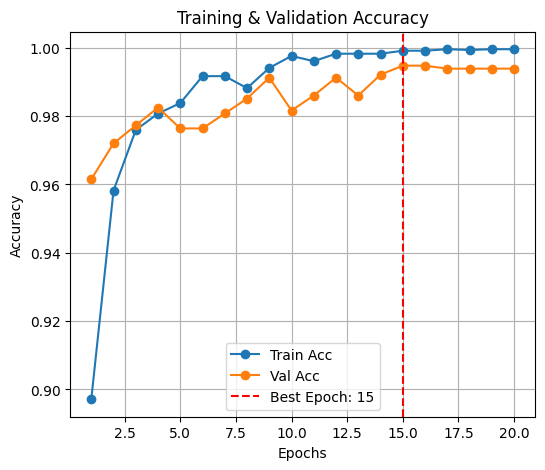

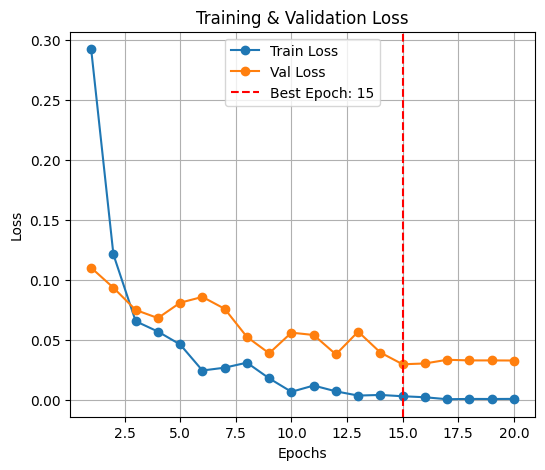

In [7]:
# Accuracy & Loss plots
import matplotlib.pyplot as plt
epochs_range = range(1, len(history["train_acc"])+1)

# Determine best epoch
best_epoch = history["val_acc"].index(max(history["val_acc"])) + 1

# -----------------------
# Accuracy plot
# -----------------------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, history["train_acc"], marker='o', label="Train Acc")
plt.plot(epochs_range, history["val_acc"], marker='o', label="Val Acc")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f"Best Epoch: {best_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_plot.png", dpi=300)
plt.show()

# -----------------------
# Loss plot
# -----------------------
plt.figure(figsize=(6,5))
plt.plot(epochs_range, history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker='o', label="Val Loss")
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f"Best Epoch: {best_epoch}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_plot.png", dpi=300)
plt.show()


Baseline Test Accuracy: 0.9969

=== Classification Report ===
              precision    recall  f1-score   support

      glioma     0.9967    0.9967    0.9967       300
  meningioma     0.9935    0.9967    0.9951       306
     notumor     0.9975    0.9975    0.9975       405
   pituitary     1.0000    0.9967    0.9983       300

    accuracy                         0.9969      1311
   macro avg     0.9969    0.9969    0.9969      1311
weighted avg     0.9970    0.9969    0.9970      1311



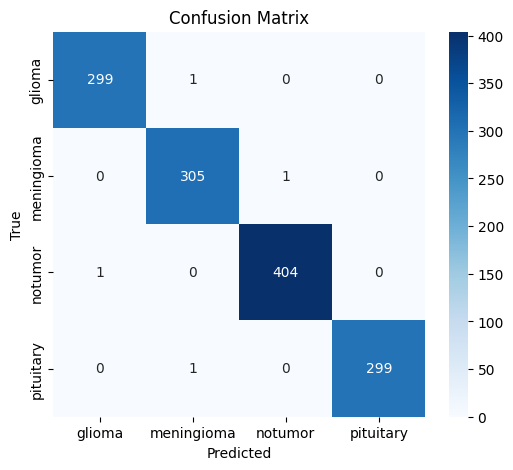


MCC: 0.9959
mAP: 0.9999


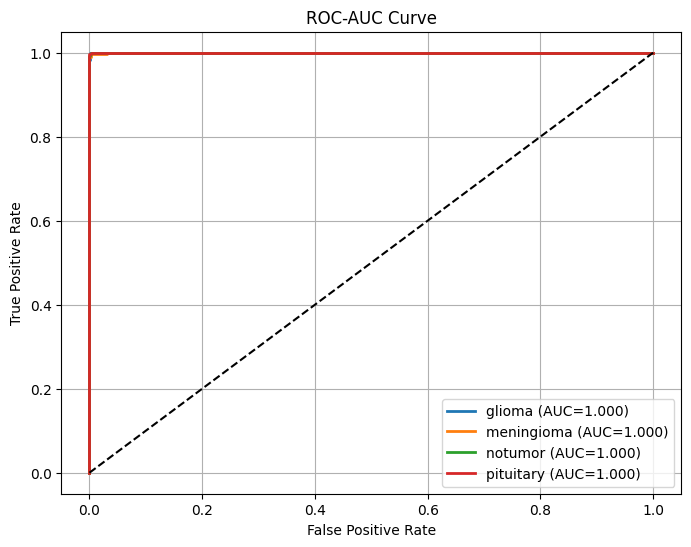

In [9]:
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=is_cuda
)

# ------------------------------
# Load Best Model (BASELINE)
# ------------------------------
model_cnx.load_state_dict(torch.load("best_convnext_baseline.pth", map_location=device))
model_cnx.eval()

# ------------------------------
# Evaluate
# ------------------------------
acc, y_pred, y_true, y_score = evaluate(model_cnx, test_loader)

print(f"Baseline Test Accuracy: {acc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=full_dataset.classes,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mcc = matthews_corrcoef(y_true, y_pred)
print(f"\nMCC: {mcc:.4f}")

y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
mAP = average_precision_score(y_true_bin, y_score, average="macro")
print(f"mAP: {mAP:.4f}")

plt.figure(figsize=(8,6))
for i, cls in enumerate(full_dataset.classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid(True)
plt.show()

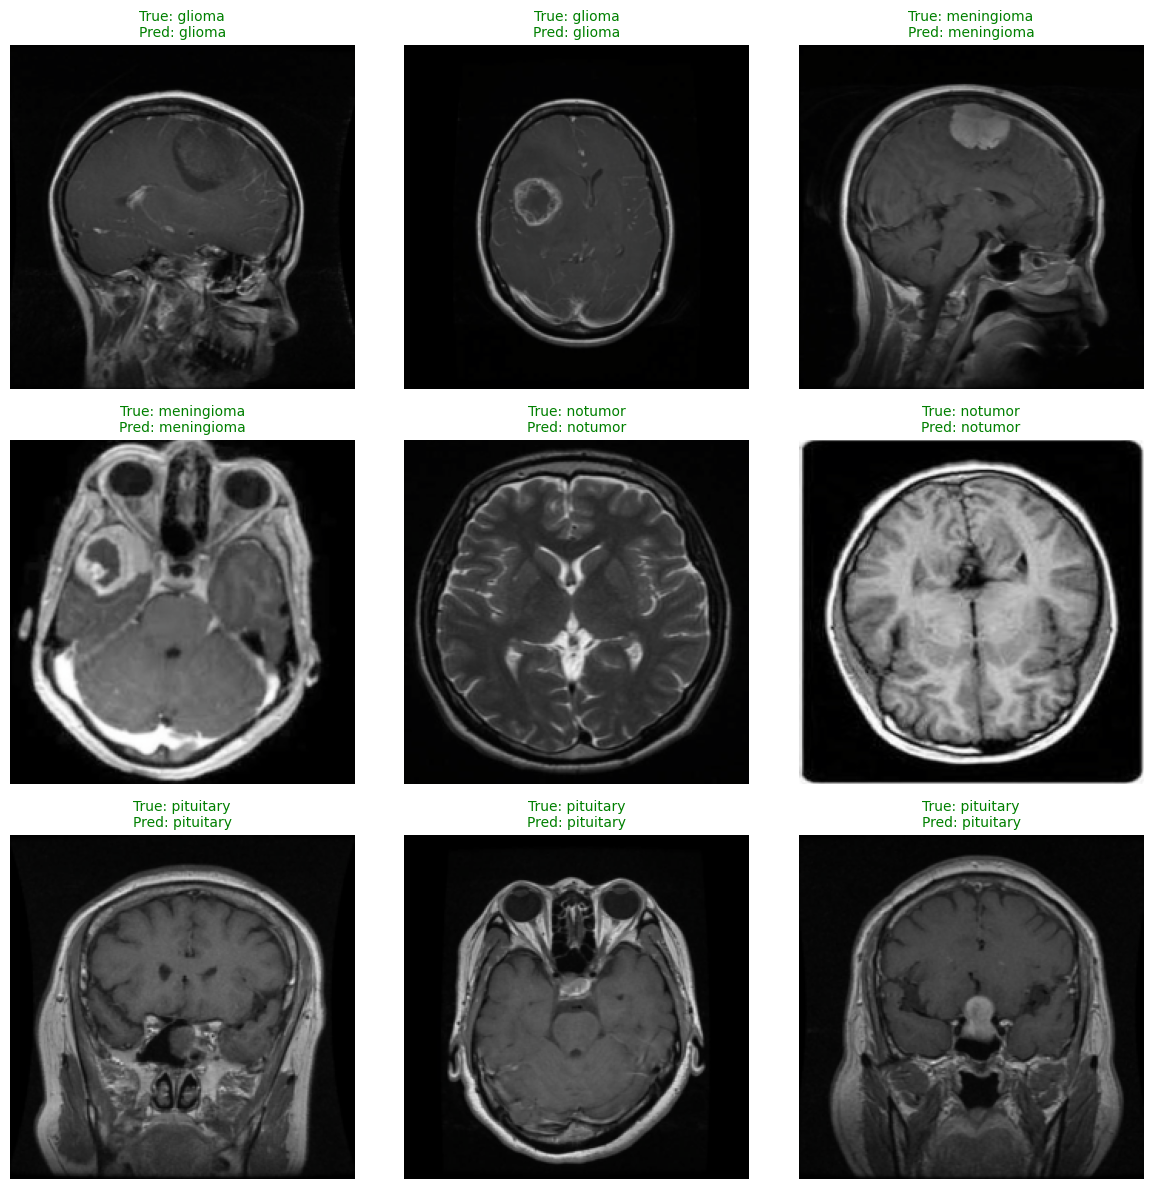

In [10]:
import torch, random
import numpy as np
import matplotlib.pyplot as plt

# ✅ Load best ConvNeXt Baseline checkpoint
model_cnx.load_state_dict(torch.load("best_convnext_baseline.pth", map_location=device))
model_cnx.eval()

# ✅ Collect indices grouped by class
class_indices = {cls: [] for cls in range(len(test_ds.classes))}
for idx in range(len(test_ds)):
    _, lbl = test_ds[idx]
    class_indices[lbl].append(idx)

# ✅ Pick up to 9 samples (roughly balanced across classes)
samples = []
per_class = max(1, 9 // len(class_indices))
for cls, idxs in class_indices.items():
    k = min(per_class, len(idxs))
    samples.extend(random.sample(idxs, k))
while len(samples) < 9:  # fill remaining if fewer than 9
    samples.append(random.randint(0, len(test_ds)-1))

# ✅ Plot images with predictions
plt.figure(figsize=(12,12))
for i, idx in enumerate(samples):
    img, true_label = test_ds[idx]
    img_in = img.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model_cnx(img_in)
    pred_label = out.argmax(dim=1).item()

    # Undo normalization for display
    img_disp = img.cpu().numpy().transpose(1,2,0)
    img_disp = np.clip(
        img_disp * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]),
        0, 1
    )

    plt.subplot(3,3,i+1)
    plt.imshow(img_disp)
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {test_ds.classes[true_label]}\nPred: {test_ds.classes[pred_label]}",
              color=color, fontsize=10)
    plt.axis("off")

plt.tight_layout()


In [11]:
# Load the best checkpoint
best_model_state = torch.load("best_convnext_baseline.pth", map_location=device)

# Create the target directory if it doesn't exist
output_dir = "/kaggle/working"
os.makedirs(output_dir, exist_ok=True)

# Save it with a new filename
torch.save(best_model_state, os.path.join(output_dir, "final_convnext_baseline.pth"))
print("✅ Best model saved as final_convnext_baseline.pth")

✅ Best model saved as final_convnext_baseline.pth
